In [9]:
import os
import torch, torch.nn as nn, torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [10]:
csv_path = 'Iris.csv'

# ── Data
df  = pd.read_csv(csv_path)
X   = StandardScaler().fit_transform(df.drop(["Id","Species"], axis=1).values)
y   = LabelEncoder().fit_transform(df["Species"].values)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
X_te = torch.tensor(X_te, dtype=torch.float32)
y_te = torch.tensor(y_te, dtype=torch.long)

In [11]:
# ── Model factory
# Fresh model per optimizer — essential for a fair comparison.
# If all optimizers shared one model, the second optimizer would start from
# weights already tuned by the first.
def make_model():
    sizes = [4, 128, 128, 128, 128, 128, 128]
    layers = []
    for i in range(len(sizes)-1):
        layers += [nn.Linear(sizes[i], sizes[i+1]), nn.ReLU()]  # ReLU, not Sigmoid
    layers.append(nn.Linear(128, 3))
    return nn.Sequential(*layers)

### SGD
$$w_{t+1} = w_t - \eta \nabla L(w_t)$$

### SGD + Momentum
$$v_t = \gamma v_{t-1} + \eta \nabla L(w_t)$$
$$w_{t+1} = w_t - v_t$$


### RMSProp
$$E[g^2]_t = \beta E[g^2]_{t-1} + (1 - \beta)g_t^2$$
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \cdot g_t$$

### Adam
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)g_t^2$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

### AdaGrad
$$v_t = v_{t-1} + g_t^2$$
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{v_t + \epsilon}} \cdot v_t$$


In [12]:
# ── Optimizers under comparison
# Each entry: (display name, optimizer class, kwargs)
# Adding a new optimizer = one new line here, nothing else changes.
OPTIMIZERS = [
    ("SGD",         optim.SGD,     {"lr": 0.01}),
    ("SGD+Momentum",optim.SGD,     {"lr": 0.01, "momentum": 0.9}),
    # RMSProp: adapts lr per-parameter using a running mean of squared gradients
    # good for non-stationary problems; precursor to Adam
    ("RMSProp",     optim.RMSprop, {"lr": 0.01}),
    # Adam: momentum + RMSProp combined + bias correction
    # m̂ = smoothed gradient,  v̂ = smoothed squared gradient
    # update = lr * m̂ / (√v̂ + ε)  — large historical gradients → smaller steps
    ("Adam",        optim.Adam,    {"lr": 0.001}),
    # AdaGrad: accumulates ALL past squared gradients (never forgets)
    # learning rate decays monotonically → eventually stops learning
    ("AdaGrad",     optim.Adagrad, {"lr": 0.01}),
]

In [13]:
# ── Train one model with one optimizer, return loss + accuracy curves
def train(opt_class, opt_kwargs, epochs=100):
    model = make_model()
    opt   = opt_class(model.parameters(), **opt_kwargs)
    crit  = nn.CrossEntropyLoss()
    losses, accs = [], []

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out  = model(X_tr)
        loss = crit(out, y_tr)
        loss.backward()
        opt.step()
        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            preds = model(X_te).argmax(dim=1)
            accs.append((preds == y_te).float().mean().item())

    return losses, accs

In [14]:
# ── Run all optimizers
results = {name: train(cls, kw) for name, cls, kw in OPTIMIZERS}

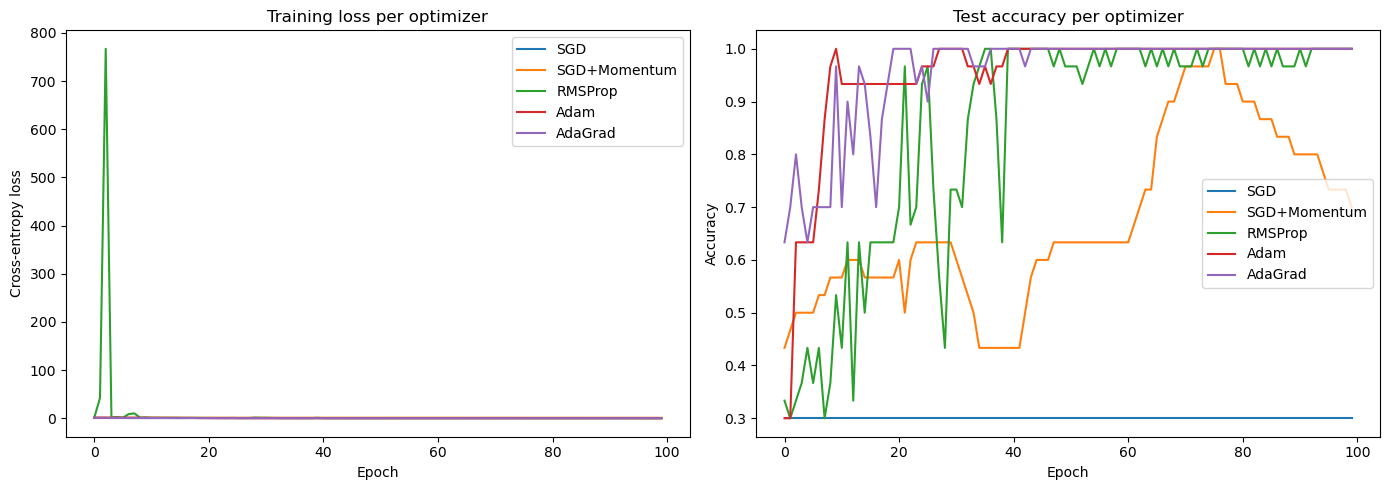


Optimizer          Final Loss   Test Acc
----------------------------------------
SGD                    1.0952     30.0%
SGD+Momentum           0.9064     70.0%
RMSProp                0.0349    100.0%
Adam                   0.0133    100.0%
AdaGrad                0.0228    100.0%


In [15]:
# ── Plot: loss + accuracy side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, (losses, accs) in results.items():
    ax1.plot(losses, label=name)
    ax2.plot(accs,   label=name)

ax1.set_title("Training loss per optimizer");  ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax2.set_title("Test accuracy per optimizer");  ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax1.legend(); ax2.legend()
plt.tight_layout(); plt.show()

# ── Final summary
print(f"\n{'Optimizer':<16} {'Final Loss':>12} {'Test Acc':>10}")
print("-" * 40)
for name, (losses, accs) in results.items():
    print(f"{name:<16} {losses[-1]:>12.4f} {accs[-1]:>9.1%}")